# **Analisis dan Klasifikasi Cuaca Australia**
## *Rain in Australia — Prediksi Hujan Esok Hari*

---

| Identitas | |
|-----------|--|
| **Nama** | Alfian Adi Pratama |
| **NIM** | 2304010008 |
| **Prodi** | D3 Statistika Terapan dan Komputasi |

---

### 📋 Deskripsi Dataset
Dataset **Rain in Australia** berisi data observasi cuaca harian dari 49 lokasi di Australia selama periode **November 2007 – Juni 2017** (≈10 tahun). 
Dataset ini bersumber dari **Australian Bureau of Meteorology** dan tersedia secara publik di Kaggle.

**Tujuan:** Melakukan **Klasifikasi** untuk memprediksi apakah besok akan hujan (`RainTomorrow`: Yes/No) berdasarkan kondisi cuaca hari ini, menggunakan berbagai algoritma machine learning beserta optimasi hiperparameter.

**Sumber:** https://www.kaggle.com/datasets/jsphyg/weather-dataset-rattle-package?select=weatherAUS.csv

### 🗂️ Alur Notebook
| No | Tahap | Fokus |
|----|-------|-------|
| 1 | **Import Library** | Setup environment |
| 2 | **Load Data** | Baca dataset asli |
| 3 | **Preprocessing** | Persiapan data sebelum modeling |
| 4 | **Simpan Data** | CSV & Parquet |
| 5 | **EDA** | Eksplorasi visual |
| 6 | **Modeling** | Klasifikasi dengan 4 model + Bayesian Optimization |

---

# **1. Import Library**

Import semua library yang dibutuhkan di awal notebook agar lebih terorganisir dan mudah dipantau dependensinya.

In [ ]:
%pip install scikit-optimize

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (classification_report, ConfusionMatrixDisplay,
                             f1_score, roc_auc_score, roc_curve, auc)
from skopt import BayesSearchCV
from skopt.space import Real, Integer, Categorical

pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', '{:.2f}'.format)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

print('Semua library berhasil diimport!')
print(f'   pandas  : {pd.__version__}')
print(f'   numpy   : {np.__version__}')

Semua library berhasil diimport!
   pandas  : 2.2.3
   numpy   : 1.26.4


# **2. Load Data**

Membaca file CSV ke dalam DataFrame pandas, kemudian melakukan pengecekan awal untuk memahami struktur data sebelum preprocessing.

In [2]:
df_raw = pd.read_csv('weatherAUS.csv')

print(f'Dimensi dataset : {df_raw.shape[0]:,} baris × {df_raw.shape[1]} kolom')
print(f'Periode data    : {df_raw["Date"].min()} s.d. {df_raw["Date"].max()}')
print(f'Jumlah lokasi   : {df_raw["Location"].nunique()} kota di Australia')

Dimensi dataset : 145,460 baris × 23 kolom
Periode data    : 2007-11-01 s.d. 2017-06-25
Jumlah lokasi   : 49 kota di Australia


In [3]:
# Tampilkan 5 baris pertama
df_raw.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.40,22.90,0.60,NaN,NaN,W,44.00,W,WNW,20.00,24.00,71.00,22.00,1007.70,1007.10,8.00,NaN,16.90,21.80,No,No
1,2008-12-02,Albury,7.40,25.10,0.00,NaN,NaN,WNW,44.00,NNW,WSW,4.00,22.00,44.00,25.00,1010.60,1007.80,NaN,NaN,17.20,24.30,No,No
2,2008-12-03,Albury,12.90,25.70,0.00,NaN,NaN,WSW,46.00,W,WSW,19.00,26.00,38.00,30.00,1007.60,1008.70,NaN,2.00,21.00,23.20,No,No
3,2008-12-04,Albury,9.20,28.00,0.00,NaN,NaN,NE,24.00,SE,E,11.00,9.00,45.00,16.00,1017.60,1012.80,NaN,NaN,18.10,26.50,No,No
4,2008-12-05,Albury,17.50,32.30,1.00,NaN,NaN,W,41.00,ENE,NW,7.00,20.00,82.00,33.00,1010.80,1006.00,7.00,8.00,17.80,29.70,No,No


In [4]:
# Tipe data setiap kolom
print('=== Tipe Data Kolom ===')
print(df_raw.dtypes)
print(f'\nTotal: {df_raw.select_dtypes(include="number").shape[1]} kolom numerik, '
      f'{df_raw.select_dtypes(include="object").shape[1]} kolom kategorikal/teks')

=== Tipe Data Kolom ===
Date              object
Location          object
MinTemp          float64
MaxTemp          float64
Rainfall         float64
Evaporation      float64
Sunshine         float64
WindGustDir       object
WindGustSpeed    float64
WindDir9am        object
WindDir3pm        object
WindSpeed9am     float64
WindSpeed3pm     float64
Humidity9am      float64
Humidity3pm      float64
Pressure9am      float64
Pressure3pm      float64
Cloud9am         float64
Cloud3pm         float64
Temp9am          float64
Temp3pm          float64
RainToday         object
RainTomorrow      object
dtype: object

Total: 16 kolom numerik, 7 kolom kategorikal/teks


In [5]:
# Statistik deskriptif kolom numerik
print('=== Statistik Deskriptif ===')
df_raw.describe()

=== Statistik Deskriptif ===


,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm
count,143975.00,144199.00,142199.00,82670.00,75625.00,135197.00,143693.00,142398.00,142806.00,140953.00,130395.00,130432.00,89572.00,86102.00,143693.00,141851.00
mean,12.19,23.22,2.36,5.47,7.61,40.04,14.04,18.66,68.88,51.54,1017.65,1015.26,4.45,4.51,16.99,21.68
std,6.40,7.12,8.48,4.19,3.79,13.61,8.92,8.81,19.03,20.80,7.11,7.04,2.89,2.72,6.49,6.94
min,-8.50,-4.80,0.00,0.00,0.00,6.00,0.00,0.00,0.00,0.00,980.50,977.10,0.00,0.00,-7.20,-5.40
25%,7.60,17.90,0.00,2.60,4.80,31.00,7.00,13.00,57.00,37.00,1012.90,1010.40,1.00,2.00,12.30,16.60
50%,12.00,22.60,0.00,4.80,8.40,39.00,13.00,19.00,70.00,52.00,1017.60,1015.20,5.00,5.00,16.70,21.10
75%,16.90,28.20,0.80,7.40,10.60,48.00,19.00,24.00,83.00,66.00,1022.40,1020.00,7.00,7.00,21.60,26.40
max,33.90,48.10,371.00,145.00,14.50,135.00,130.00,87.00,100.00,100.00,1041.00,1039.60,9.00,9.00,40.20,46.70


---
# **3. Preprocessing**
> Tahap ini adalah **fondasi utama** sebelum modeling. Preprocessing yang baik sangat menentukan kualitas model klasifikasi yang dihasilkan.

## 3.1 Salin Data Mentah
Selalu bekerja pada salinan data, bukan data asli, agar data mentah tetap tersimpan sebagai referensi jika sewaktu-waktu dibutuhkan.

In [6]:
df = df_raw.copy()
print(f'Data berhasil disalin. Shape: {df.shape}')

Data berhasil disalin. Shape: (145460, 23)


## 3.2 Hapus Baris Duplikat
Baris yang identik dapat membuat model belajar pola yang sama berkali-kali, sehingga menyebabkan bias.

In [7]:
n_before = len(df)
df.drop_duplicates(inplace=True)
n_after = len(df)

print(f'Baris sebelum : {n_before:,}')
print(f'Baris setelah : {n_after:,}')
print(f'Duplikat dihapus: {n_before - n_after} baris')

Baris sebelum : 145,460
Baris setelah : 145,460
Duplikat dihapus: 0 baris


## 3.3 Hapus Baris dengan Target Kosong
Baris yang kolom targetnya (`RainTomorrow`) kosong tidak dapat digunakan untuk training maupun evaluasi, sehingga harus dihapus terlebih dahulu.

In [8]:
n_before = len(df)
df.dropna(subset=['RainTomorrow'], inplace=True)
n_after = len(df)

print(f'Baris sebelum : {n_before:,}')
print(f'Baris setelah : {n_after:,}')
print(f'Dihapus       : {n_before - n_after} baris (target NaN)')
print(f'\nDistribusi target:')
print(df['RainTomorrow'].value_counts())
print(f'\nCatatan: Data tidak seimbang (imbalanced) — No: {df["RainTomorrow"].value_counts()["No"]:,} | Yes: {df["RainTomorrow"].value_counts()["Yes"]:,}')

Baris sebelum : 145,460
Baris setelah : 142,193
Dihapus       : 3267 baris (target NaN)

Distribusi target:
RainTomorrow
No     110316
Yes     31877
Name: count, dtype: int64

Catatan: Data tidak seimbang (imbalanced) — No: 110,316 | Yes: 31,877


## 3.4 Ekstraksi Fitur dari Kolom Date
Kolom `Date` berformat string tidak langsung berguna untuk model. Kita ekstrak komponen `Year`, `Month`, dan `Day` sebagai fitur numerik yang lebih informatif. Kolom `Date` asli kemudian dihapus.

In [9]:
df['Date'] = pd.to_datetime(df['Date'])
df['Year']  = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day']   = df['Date'].dt.day
df.drop(columns=['Date'], inplace=True)

print('Fitur baru hasil ekstraksi Date:')
print(df[['Year','Month','Day']].head())
print(f'\nRentang tahun: {df["Year"].min()} – {df["Year"].max()}')
print(f'Bulan unik   : {sorted(df["Month"].unique())}')

Fitur baru hasil ekstraksi Date:
   Year  Month  Day
0  2008     12    1
1  2008     12    2
2  2008     12    3
3  2008     12    4
4  2008     12    5

Rentang tahun: 2007 – 2017
Bulan unik   : [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]


## 3.5 Penanganan Missing Values
Dataset ini memiliki missing values yang cukup banyak pada beberapa kolom. Strategi imputasi dibedakan berdasarkan tipe kolom:
- **Kolom numerik** → diisi dengan **median** (lebih robust terhadap outlier dibanding mean)
- **Kolom kategorikal** → diisi dengan **modus** (nilai yang paling sering muncul)

In [10]:
# Ringkasan missing values sebelum imputasi
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Jumlah Missing': missing,
    'Persentase (%)': missing_pct
}).query('`Jumlah Missing` > 0').sort_values('Persentase (%)', ascending=False)

print('=== Missing Values Sebelum Imputasi ===')
print(missing_df)
print(f'\nTotal kolom dengan missing: {len(missing_df)}')

=== Missing Values Sebelum Imputasi ===
               Jumlah Missing  Persentase (%)
Sunshine                67816           47.69
Evaporation             60843           42.79
Cloud3pm                57094           40.15
Cloud9am                53657           37.74
Pressure9am             14014            9.86
Pressure3pm             13981            9.83
WindDir9am              10013            7.04
WindGustDir              9330            6.56
WindGustSpeed            9270            6.52
WindDir3pm               3778            2.66
Humidity3pm              3610            2.54
Temp3pm                  2726            1.92
WindSpeed3pm             2630            1.85
Humidity9am              1774            1.25
RainToday                1406            0.99
Rainfall                 1406            0.99
WindSpeed9am             1348            0.95
Temp9am                   904            0.64
MinTemp                   637            0.45
MaxTemp                   322           

In [11]:
# Kolom numerik: isi dengan median
num_cols = df.select_dtypes(include='number').columns.tolist()
for col in num_cols:
    if df[col].isnull().sum() > 0:
        median_val = df[col].median()
        df[col].fillna(median_val, inplace=True)

# Kolom kategorikal: isi dengan modus
cat_cols = df.select_dtypes(include='object').columns.tolist()
cat_cols = [c for c in cat_cols if c != 'RainTomorrow']  # kecualikan target
for col in cat_cols:
    if df[col].isnull().sum() > 0:
        modus_val = df[col].mode()[0]
        df[col].fillna(modus_val, inplace=True)

# Verifikasi
total_missing_after = df.isnull().sum().sum()
print(f'Total missing values setelah imputasi: {total_missing_after}')
print('Semua missing values berhasil ditangani!')

Total missing values setelah imputasi: 0
Semua missing values berhasil ditangani!


## 3.6 Deteksi dan Penanganan Outlier (IQR Method)
Outlier dapat mendistorsi model, terutama model berbasis jarak seperti KNN. Metode **IQR (Interquartile Range)** digunakan untuk mendeteksi dan menggantinya dengan nilai batas atas/bawah yang wajar (*winsorizing*).

**Rumus batas:**
- Batas bawah = Q1 − 1.5 × IQR
- Batas atas = Q3 + 1.5 × IQR

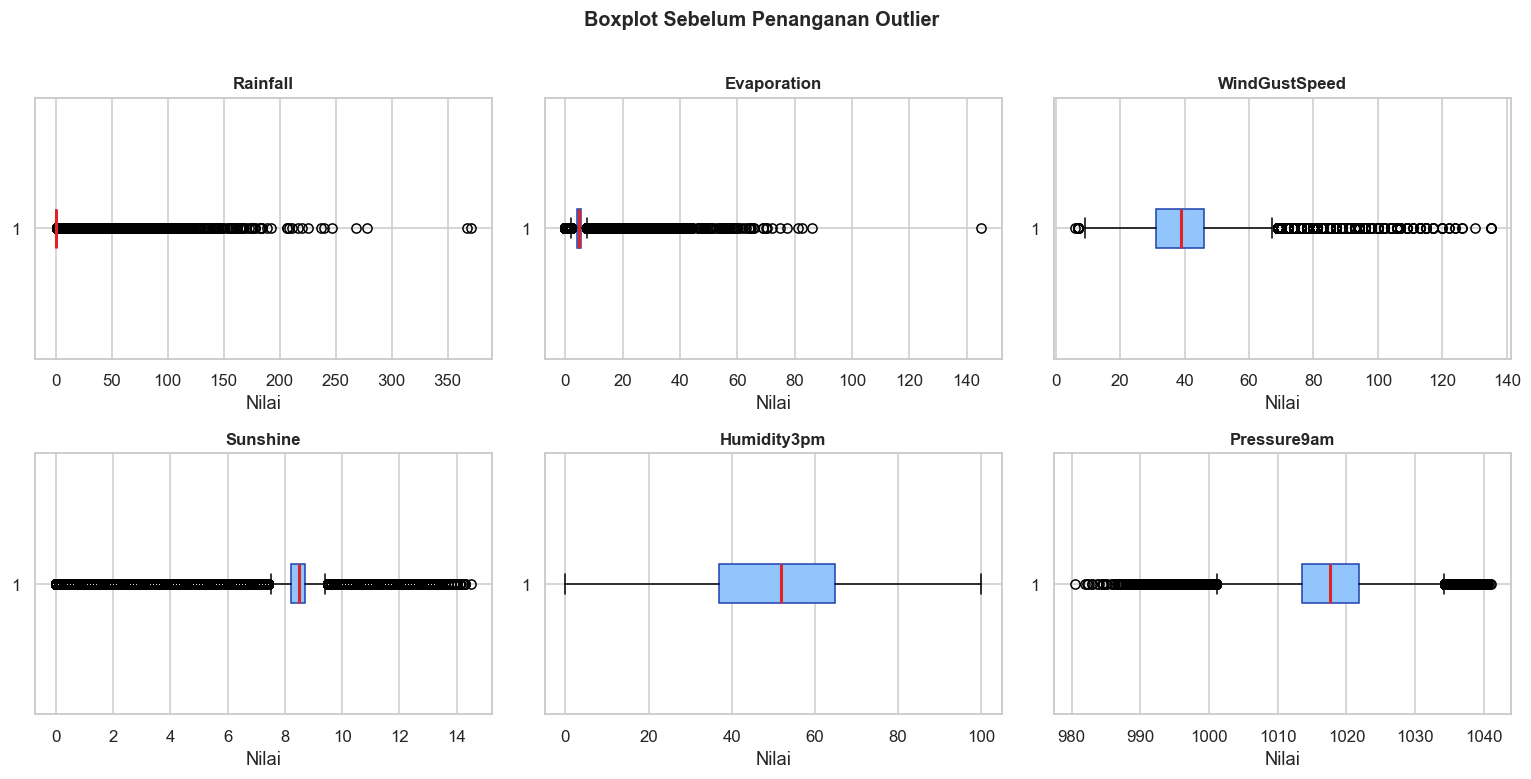

Titik-titik di luar whisker (garis panjang) merupakan outlier yang perlu ditangani.


In [12]:
# Visualisasi outlier sebelum handling — pilih 6 kolom representatif
cols_viz = ['Rainfall','Evaporation','WindGustSpeed','Sunshine','Humidity3pm','Pressure9am']

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.flatten()
for i, col in enumerate(cols_viz):
    axes[i].boxplot(df[col].dropna(), vert=False, patch_artist=True,
                   boxprops=dict(facecolor='#93C5FD', color='#1E40AF'),
                   medianprops=dict(color='#DC2626', linewidth=2))
    axes[i].set_title(col, fontweight='bold', fontsize=11)
    axes[i].set_xlabel('Nilai')
fig.suptitle('Boxplot Sebelum Penanganan Outlier', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()
print('Titik-titik di luar whisker (garis panjang) merupakan outlier yang perlu ditangani.')

In [13]:
# Winsorizing dengan metode IQR
outlier_report = []
num_features = [c for c in df.select_dtypes(include='number').columns
                if c not in ['Year','Month','Day']]

for col in num_features:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    if n_out > 0:
        df[col] = df[col].clip(lower=lower, upper=upper)
        outlier_report.append({'Kolom': col, 'Outlier Ditangani': n_out,
                               'Batas Bawah': round(lower,2), 'Batas Atas': round(upper,2)})

report_df = pd.DataFrame(outlier_report).sort_values('Outlier Ditangani', ascending=False)
print('=== Laporan Penanganan Outlier ===')
print(report_df.to_string(index=False))
print(f'\nTotal kolom dengan outlier: {len(report_df)}')
print('Outlier diganti dengan nilai batas (winsorizing), bukan dihapus.')

=== Laporan Penanganan Outlier ===
        Kolom  Outlier Ditangani  Batas Bawah  Batas Atas
     Sunshine              60823         7.45        9.45
  Evaporation              32317         1.90        7.50
     Rainfall              28545        -0.90        1.50
WindGustSpeed               5386         8.50       68.50
     Cloud3pm               4957         1.00        9.00
  Pressure9am               2708      1001.05     1034.25
 WindSpeed3pm               2458        -3.50       40.50
  Pressure3pm               2305       998.40     1032.00
 WindSpeed9am               1739       -11.00       37.00
  Humidity9am               1419        18.00      122.00
      Temp3pm                840         2.30       40.70
      MaxTemp                459         2.45       43.65
      Temp9am                292        -1.50       35.30
      MinTemp                 62        -6.20       30.60

Total kolom dengan outlier: 14
Outlier diganti dengan nilai batas (winsorizing), bukan dihapus

## 3.7 Encoding Kolom Kategorikal
Model machine learning hanya dapat memproses angka. Oleh karena itu, semua kolom bertipe teks/kategori harus dikonversi ke angka:
- **`RainToday` & `RainTomorrow`** → Binary encoding (Yes=1, No=0)
- **Kolom arah angin & Location** → Label Encoding

In [14]:
# Binary encoding untuk RainToday dan RainTomorrow
df['RainToday']    = df['RainToday'].map({'Yes': 1, 'No': 0})
df['RainTomorrow'] = df['RainTomorrow'].map({'Yes': 1, 'No': 0})

print('Mapping RainToday & RainTomorrow: Yes=1, No=0')
print(df[['RainToday','RainTomorrow']].value_counts().head())

Mapping RainToday & RainTomorrow: Yes=1, No=0
RainToday  RainTomorrow
0          0               93458
           1               17280
1          0               16858
           1               14597
Name: count, dtype: int64


In [15]:
# Label Encoding untuk kolom kategorikal lainnya
le = LabelEncoder()
cat_remaining = df.select_dtypes(include='object').columns.tolist()
print('Kolom yang akan di-encode:')

for col in cat_remaining:
    df[col] = le.fit_transform(df[col].astype(str))
    print(f'  {col:15s} → {df[col].nunique()} nilai unik')

print('\nEncoding selesai!')
print(f'Semua kolom kini bertipe numerik: {df.select_dtypes(include="object").shape[1]} kolom object tersisa')

Kolom yang akan di-encode:
  Location        → 49 nilai unik
  WindGustDir     → 16 nilai unik
  WindDir9am      → 16 nilai unik
  WindDir3pm      → 16 nilai unik

Encoding selesai!
Semua kolom kini bertipe numerik: 0 kolom object tersisa


## 3.8 Feature Scaling (StandardScaler)
Karena kolom-kolom memiliki skala yang sangat berbeda (misalnya suhu 0–50 vs tekanan 990–1040), model berbasis jarak seperti KNN akan didominasi oleh fitur berskala besar. **StandardScaler** menstandardisasi setiap fitur agar memiliki mean=0 dan std=1.

> ⚠️ Scaler di-`fit` **hanya pada data training** dan di-`transform` pada data test — untuk menghindari *data leakage*.

In [16]:
# Pisahkan fitur dan target
X = df.drop(columns=['RainTomorrow'])
y = df['RainTomorrow']

# Train-test split (80:20, stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scaling
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'X_train : {X_train.shape}  → X_train_scaled : {X_train_sc.shape}')
print(f'X_test  : {X_test.shape}   → X_test_scaled  : {X_test_sc.shape}')
print(f'\nDistribusi kelas train :')
vc = y_train.value_counts()
print(f'  No (0) : {vc[0]:,} ({vc[0]/len(y_train)*100:.1f}%)')
print(f'  Yes(1) : {vc[1]:,} ({vc[1]/len(y_train)*100:.1f}%)')
print('\nPreprocessing selesai! Data siap disimpan dan digunakan untuk modeling.')

X_train : (113754, 24)  → X_train_scaled : (113754, 24)
X_test  : (28439, 24)   → X_test_scaled  : (28439, 24)

Distribusi kelas train :
  No (0) : 88,252 (77.6%)
  Yes(1) : 25,502 (22.4%)

Preprocessing selesai! Data siap disimpan dan digunakan untuk modeling.


---
# **4. Simpan Data Hasil Preprocessing**
Data yang sudah bersih disimpan dalam dua format:
- **CSV** — format universal, mudah dibuka di Excel atau tools lain
- **Parquet** — format kolumnar yang lebih efisien untuk analisis skala besar (ukuran file lebih kecil, pembacaan lebih cepat)

In [17]:
# Simpan data hasil preprocessing lengkap
df_clean = df.copy()

# Simpan CSV
df_clean.to_csv('weatherAUS_clean.csv', index=False)

# Simpan Parquet
df_clean.to_parquet('weatherAUS_clean.parquet', index=False)

import os
csv_size     = os.path.getsize('weatherAUS_clean.csv') / 1024
parquet_size = os.path.getsize('weatherAUS_clean.parquet') / 1024

print('=== File Tersimpan ===')
print(f'weatherAUS_clean.csv     : {csv_size:,.1f} KB')
print(f'weatherAUS_clean.parquet : {parquet_size:,.1f} KB')
print(f'\nParquet {(1 - parquet_size/csv_size)*100:.1f}% lebih kecil dari CSV!')
print(f'\nShape data tersimpan: {df_clean.shape}')

=== File Tersimpan ===
weatherAUS_clean.csv     : 15,232.2 KB
weatherAUS_clean.parquet : 1,939.6 KB

Parquet 87.3% lebih kecil dari CSV!

Shape data tersimpan: (142193, 25)


In [18]:
# Verifikasi: baca kembali dari parquet
df_parquet = pd.read_parquet('weatherAUS_clean.parquet')
print(f'Verifikasi parquet — Shape : {df_parquet.shape}')
print(f'Kolom : {df_parquet.columns.tolist()}')
print('\nPreview data bersih:')
df_parquet.head()

Verifikasi parquet — Shape : (142193, 25)
Kolom : ['Location', 'MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine', 'WindGustDir', 'WindGustSpeed', 'WindDir9am', 'WindDir3pm', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am', 'Temp3pm', 'RainToday', 'RainTomorrow', 'Year', 'Month', 'Day']

Preview data bersih:


,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow,Year,Month,Day
0,2,13.40,22.90,0.60,4.80,8.50,13,44.00,13,14,20.00,24.00,71.00,22.00,1007.70,1007.10,8.00,5.00,16.90,21.80,0,0,2008,12,1
1,2,7.40,25.10,0.00,4.80,8.50,14,44.00,6,15,4.00,22.00,44.00,25.00,1010.60,1007.80,5.00,5.00,17.20,24.30,0,0,2008,12,2
2,2,12.90,25.70,0.00,4.80,8.50,15,46.00,13,15,19.00,26.00,38.00,30.00,1007.60,1008.70,5.00,2.00,21.00,23.20,0,0,2008,12,3
3,2,9.20,28.00,0.00,4.80,8.50,4,24.00,9,0,11.00,9.00,45.00,16.00,1017.60,1012.80,5.00,5.00,18.10,26.50,0,0,2008,12,4
4,2,17.50,32.30,1.00,4.80,8.50,13,41.00,1,7,7.00,20.00,82.00,33.00,1010.80,1006.00,7.00,8.00,17.80,29.70,0,0,2008,12,5


---
# **5. Exploratory Data Analysis (EDA)**
> EDA dilakukan menggunakan data dari file **Parquet** yang sudah bersih.

In [19]:
# Load dari parquet
df_eda = pd.read_parquet('weatherAUS_clean.parquet')
print(f'Data EDA dimuat dari parquet. Shape: {df_eda.shape}')

Data EDA dimuat dari parquet. Shape: (142193, 25)


## 5.1 Distribusi Target

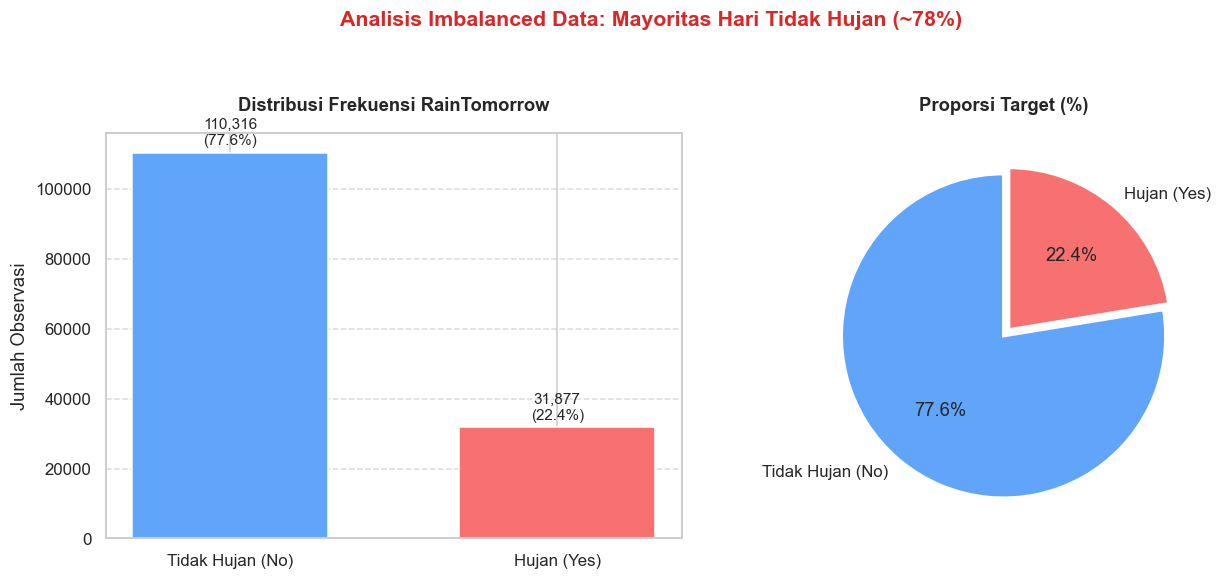

In [20]:
import matplotlib.pyplot as plt

colors = ['#60A5FA', '#F87171']
labels = ['Tidak Hujan (No)', 'Hujan (Yes)']
counts = df_eda['RainTomorrow'].value_counts().sort_index()
total = len(df_eda)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

bars = axes[0].bar(labels, counts.values, color=colors, width=0.6, edgecolor='white')
axes[0].set_title('Distribusi Frekuensi RainTomorrow', fontweight='bold', pad=15)
axes[0].set_ylabel('Jumlah Observasi')
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

for i, v in enumerate(counts.values):
    percentage = (v / total) * 100
    axes[0].text(i, v + (total * 0.01), f'{v:,}\n({percentage:.1f}%)', 
                 ha='center', va='bottom', fontsize=10, fontweight='medium')

axes[1].pie(counts.values, labels=labels, colors=colors, autopct='%1.1f%%', 
            startangle=90, explode=(0, 0.05), wedgeprops={'edgecolor':'white', 'linewidth':2})
axes[1].set_title('Proporsi Target (%)', fontweight='bold', pad=15)

plt.suptitle('Analisis Imbalanced Data: Mayoritas Hari Tidak Hujan (~78%)', 
             fontsize=14, fontweight='bold', color='#DC2626', y=1.05)

plt.tight_layout()
plt.show()

**Insight Strategis:**
1. **Ketimpangan Kelas:** Terdapat gap signifikan sebesar 55.2% antara kedua kelas.
2. **Resiko Akurasi Semu (Accuracy Paradox):** Jika model memprediksi "No" untuk semua data, akurasi akan tetap tinggi (77.6%), namun model gagal total dalam mendeteksi hari hujan (Recall rendah).

## 5.2 Distribusi Fitur Numerik Utama

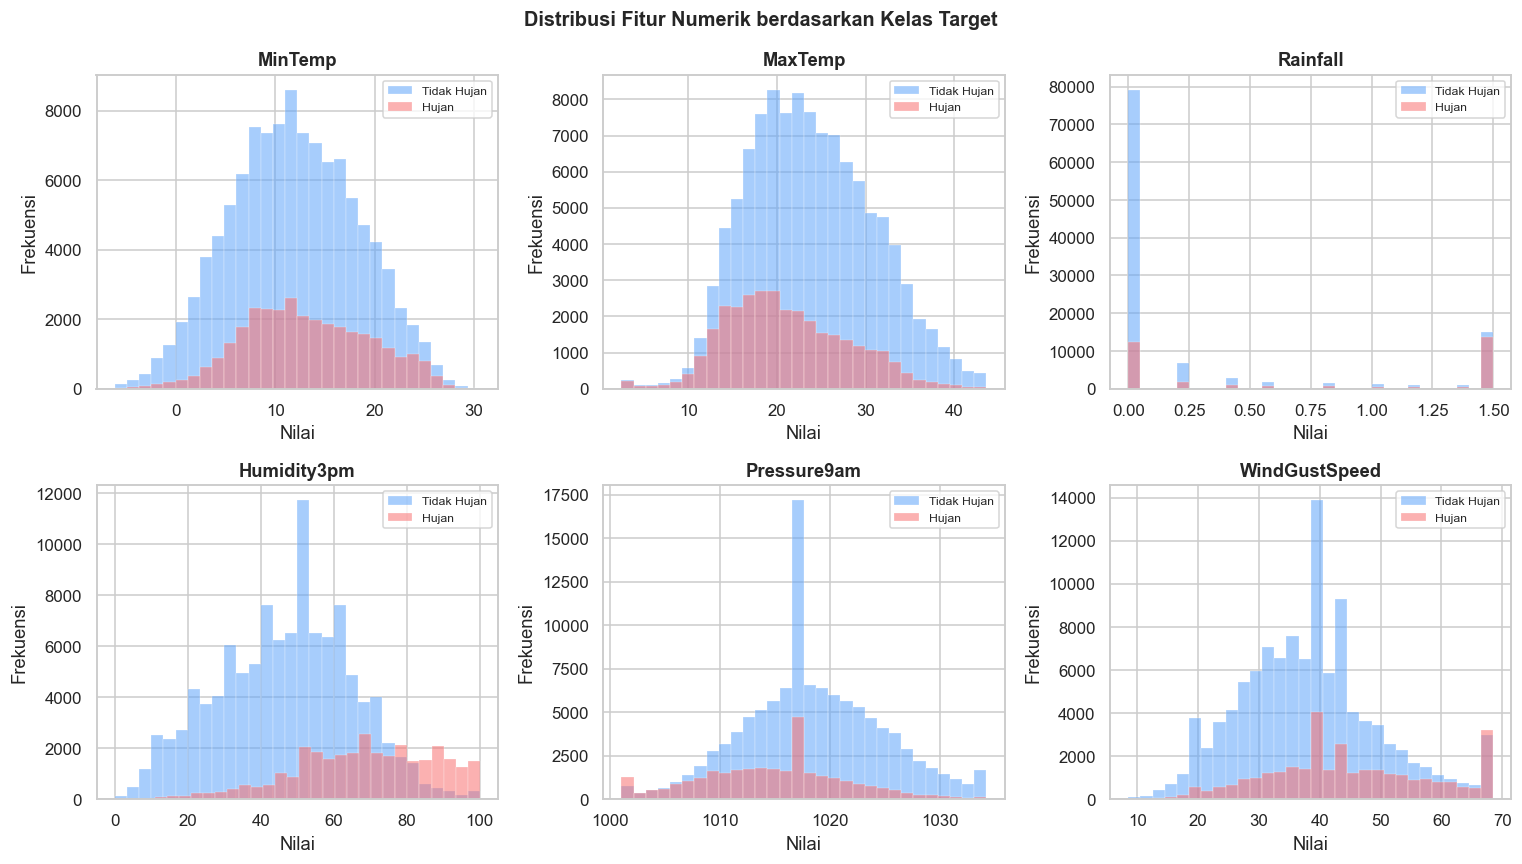

In [21]:
num_plot = ['MinTemp','MaxTemp','Rainfall','Humidity3pm','Pressure9am','WindGustSpeed']
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(num_plot):
    for val, color, label in [(0,'#60A5FA','Tidak Hujan'),(1,'#F87171','Hujan')]:
        subset = df_eda[df_eda['RainTomorrow'] == val][col]
        axes[i].hist(subset, bins=30, alpha=0.55, color=color,
                    label=label, edgecolor='white', linewidth=0.3)
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xlabel('Nilai'); axes[i].set_ylabel('Frekuensi')
    axes[i].legend(fontsize=8)

plt.suptitle('Distribusi Fitur Numerik berdasarkan Kelas Target', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Insight:**
1. **Humidity3pm dan Rainfall** menunjukkan perbedaan distribusi yang jelas antara hari hujan dan tidak — fitur yang sangat informatif.
2. **Pressure9am & WindGustSpeed:** Keduanya menunjukkan pemisahan yang moderat. Tekanan udara yang lebih rendah (Pressure9am) dan kecepatan angin yang lebih tinggi (WindGustSpeed) cenderung berkorelasi dengan probabilitas hujan yang lebih besar.
3. **MinTemp & MaxTemp:** Fitur ini memiliki overlap (tumpang tindih) yang sangat tinggi. Artinya, suhu saja (baik minimum maupun maksimum) sulit digunakan sebagai pembeda tunggal karena distribusi hari hujan dan tidak hujan hampir serupa bentuknya.

## 5.3 Heatmap Korelasi

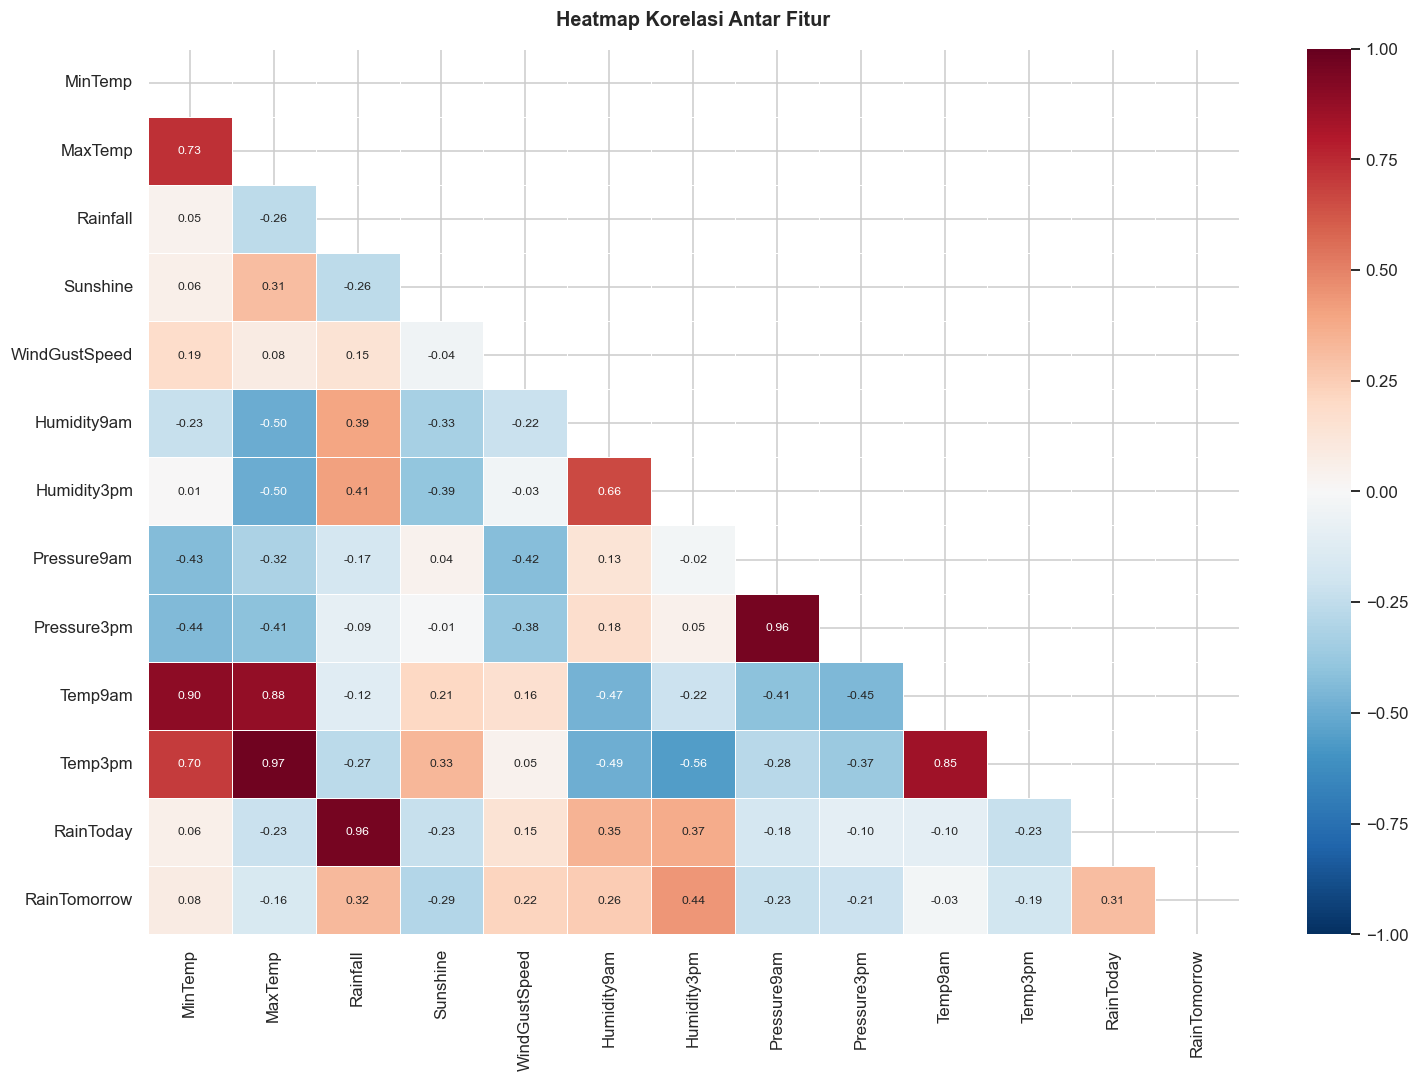

In [22]:
plt.figure(figsize=(14, 10))
corr_cols = ['MinTemp','MaxTemp','Rainfall','Sunshine','WindGustSpeed',
             'Humidity9am','Humidity3pm','Pressure9am','Pressure3pm',
             'Temp9am','Temp3pm','RainToday','RainTomorrow']
corr = df_eda[corr_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, linewidths=0.5, annot_kws={'size':8},
            vmin=-1, vmax=1)
plt.title('Heatmap Korelasi Antar Fitur', fontweight='bold', fontsize=13, pad=15)
plt.tight_layout()
plt.show()

**Insight:** Humidity3pm berkorelasi positif dengan RainTomorrow (+0.45). Pressure9am & Pressure3pm sangat berkorelasi satu sama lain (multikolinearitas).

## 5.4 Rata-rata Fitur per Kelas Target

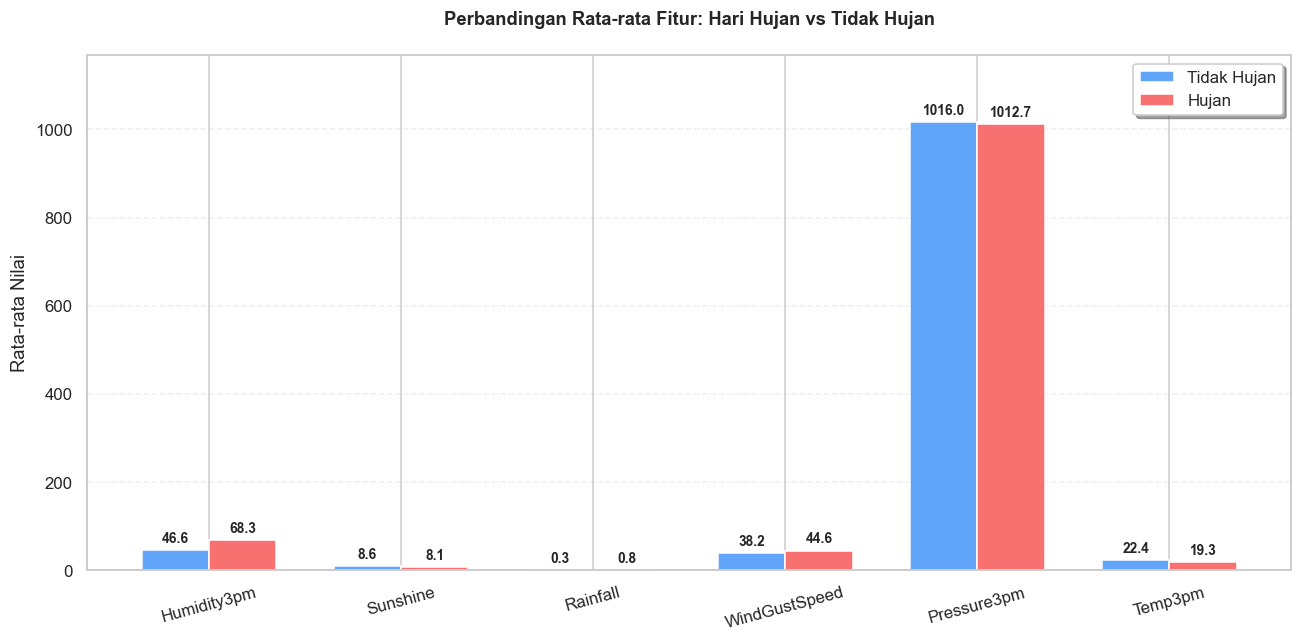

In [23]:
import matplotlib.pyplot as plt

key_feats = ['Humidity3pm', 'Sunshine', 'Rainfall', 'WindGustSpeed', 'Pressure3pm', 'Temp3pm']
mean_by_class = df_eda.groupby('RainTomorrow')[key_feats].mean().T
mean_by_class.columns = ['Tidak Hujan', 'Hujan']

fig, ax = plt.subplots(figsize=(12, 6))
x = range(len(key_feats))
width = 0.35

bars1 = ax.bar([i - width/2 for i in x], mean_by_class['Tidak Hujan'], 
               width, label='Tidak Hujan', color='#60A5FA', edgecolor='white')
bars2 = ax.bar([i + width/2 for i in x], mean_by_class['Hujan'], 
               width, label='Hujan', color='#F87171', edgecolor='white')

def autolabel(bars):
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.1f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3), 
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9, fontweight='bold')

autolabel(bars1)
autolabel(bars2)

ax.set_xticks(x)
ax.set_xticklabels(key_feats, rotation=15)
ax.set_title('Perbandingan Rata-rata Fitur: Hari Hujan vs Tidak Hujan', fontweight='bold', pad=20)
ax.set_ylabel('Rata-rata Nilai')
ax.set_ylim(0, mean_by_class.max().max() * 1.15)
ax.legend(frameon=True, shadow=True)
ax.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

**Insight:** Hari hujan cenderung memiliki kelembaban (Humidity3pm) lebih tinggi dan sinar matahari (Sunshine) lebih rendah.

---
# **6. Modeling — Klasifikasi**
> Modeling menggunakan data dari file **Parquet** yang sudah bersih. Empat algoritma klasifikasi digunakan: **KNN**, **Decision Tree**, **Random Forest**, dan **Gradient Boosting**. Setiap model dioptimasi menggunakan **Bayesian Optimization** (`BayesSearchCV`) untuk menemukan kombinasi hiperparameter terbaik secara efisien.

### Strategi Evaluasi
Mengingat data bersifat **imbalanced** (~78% No, ~22% Yes), metrik yang diutamakan adalah:
- **F1-Score** (harmonic mean dari Precision & Recall) — lebih representatif untuk data tidak seimbang
- **ROC-AUC** — mengukur kemampuan diskriminasi model secara keseluruhan
- **Recall kelas Yes** — penting agar model tidak melewatkan kejadian hujan yang sebenarnya terjadi

In [33]:
# Load data dari parquet
df_model = pd.read_parquet('weatherAUS_clean.parquet')

X_m = df_model.drop(columns=['RainTomorrow'])
y_m = df_model['RainTomorrow']

# Train-test split 80:20, stratified agar proporsi kelas terjaga
X_tr, X_te, y_tr, y_te = train_test_split(
    X_m, y_m, test_size=0.2, random_state=42, stratify=y_m
)

# Scaling — fit hanya pada train untuk menghindari data leakage
sc = StandardScaler()
X_tr_sc = sc.fit_transform(X_tr)
X_te_sc = sc.transform(X_te)

print(f'Train : {X_tr.shape} | Test : {X_te.shape}')
print(f'Proporsi kelas train — No: {(y_tr==0).sum():,} | Yes: {(y_tr==1).sum():,}')

Train : (113754, 24) | Test : (28439, 24)
Proporsi kelas train — No: 88,252 | Yes: 25,502


## 6.1 Definisi Search Space Bayesian Optimization

**Bayesian Optimization** bekerja dengan membangun model probabilistik (Gaussian Process) dari fungsi objektif, lalu secara cerdas memilih titik hiperparameter berikutnya yang paling menjanjikan berdasarkan *acquisition function* — jauh lebih efisien dibandingkan Grid Search maupun Random Search yang tidak memanfaatkan informasi dari iterasi sebelumnya.

In [25]:
# Definisi search space untuk masing-masing model
search_spaces = {
    'KNN': {
        'n_neighbors'    : Integer(3, 25),
        'weights'        : Categorical(['uniform', 'distance']),
        'metric'         : Categorical(['euclidean', 'manhattan', 'minkowski']),
        'leaf_size'      : Integer(10, 50)
    },
    'Decision Tree': {
        'max_depth'      : Integer(3, 20),
        'min_samples_split': Integer(2, 50),
        'min_samples_leaf' : Integer(1, 30),
        'criterion'      : Categorical(['gini', 'entropy']),
        'max_features'   : Categorical(['sqrt', 'log2', None])
    },
    'Random Forest': {
        'n_estimators'   : Integer(50, 300),
        'max_depth'      : Integer(3, 20),
        'min_samples_split': Integer(2, 20),
        'min_samples_leaf' : Integer(1, 15),
        'max_features'   : Categorical(['sqrt', 'log2']),
        'bootstrap'      : Categorical([True, False])
    },
    'Gradient Boosting': {
        'n_estimators'   : Integer(50, 300),
        'learning_rate'  : Real(0.01, 0.3, prior='log-uniform'),
        'max_depth'      : Integer(2, 8),
        'min_samples_split': Integer(2, 20),
        'subsample'      : Real(0.6, 1.0),
        'max_features'   : Categorical(['sqrt', 'log2'])
    }
}

# Inisialisasi model base
base_models = {
    'KNN'               : KNeighborsClassifier(n_jobs=-1),
    'Decision Tree'     : DecisionTreeClassifier(random_state=42),
    'Random Forest'     : RandomForestClassifier(random_state=42, n_jobs=-1),
    'Gradient Boosting' : GradientBoostingClassifier(random_state=42)
}

print('Search space berhasil didefinisikan untuk 4 model.')
for name, space in search_spaces.items():
    print(f'  {name:20s} → {len(space)} hiperparameter')

Search space berhasil didefinisikan untuk 4 model.
  KNN                  → 4 hiperparameter
  Decision Tree        → 5 hiperparameter
  Random Forest        → 6 hiperparameter
  Gradient Boosting    → 6 hiperparameter


## 6.2 Training dengan Bayesian Optimization

Setiap model dioptimasi menggunakan `BayesSearchCV` dengan konfigurasi:
- **n_iter = 30** iterasi pencarian per model
- **Stratified K-Fold (cv=5)** untuk validasi silang yang mempertahankan proporsi kelas
- **Scoring = F1** sebagai fungsi objektif yang dioptimasi

In [34]:
from skopt import BayesSearchCV

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

best_models    = {}
best_params    = {}
results_list   = []

for name, base_model in base_models.items():
    print(f'\n{"="*55}')
    print(f'  Optimasi: {name}')
    print(f'{"="*55}')
    
    # Gunakan data scaled untuk KNN, raw untuk tree-based
    X_fit = X_tr_sc if name == 'KNN' else X_tr
    X_eval = X_te_sc if name == 'KNN' else X_te

    bayes_search = BayesSearchCV(
        estimator   = base_model,
        search_spaces = search_spaces[name],
        n_iter      = 30,
        cv          = cv_strategy,
        scoring     = 'f1',
        n_jobs      = -1,
        random_state= 42,
        verbose     = 0
    )

    bayes_search.fit(X_fit, y_tr)

    best_model = bayes_search.best_estimator_
    best_models[name]  = best_model
    best_params[name]  = bayes_search.best_params_

    # Evaluasi pada test set
    y_pred = best_model.predict(X_eval)
    y_prob = best_model.predict_proba(X_eval)[:, 1]

    f1  = f1_score(y_te, y_pred)
    auc_score = roc_auc_score(y_te, y_prob)

    results_list.append({
        'Model'     : name,
        'Best CV F1': round(bayes_search.best_score_, 4),
        'Test F1'   : round(f1, 4),
        'ROC-AUC'   : round(auc_score, 4)
    })

    print(f'Best CV F1  : {bayes_search.best_score_:.4f}')
    print(f'Test F1     : {f1:.4f}')
    print(f'ROC-AUC     : {auc_score:.4f}')
    print(f'Best Params : {dict(bayes_search.best_params_)}')

print('\nOptimasi semua model selesai!')


  Optimasi: KNN
Best CV F1  : 0.5875
Test F1     : 0.6010
ROC-AUC     : 0.8588
Best Params : {'leaf_size': 50, 'metric': 'manhattan', 'n_neighbors': 8, 'weights': 'distance'}

  Optimasi: Decision Tree
Best CV F1  : 0.5798
Test F1     : 0.5780
ROC-AUC     : 0.8422
Best Params : {'criterion': 'entropy', 'max_depth': 20, 'max_features': None, 'min_samples_leaf': 30, 'min_samples_split': 28}

  Optimasi: Random Forest
Best CV F1  : 0.6164
Test F1     : 0.6231
ROC-AUC     : 0.8921
Best Params : {'bootstrap': False, 'max_depth': 19, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}

  Optimasi: Gradient Boosting
Best CV F1  : 0.6480
Test F1     : 0.6531
ROC-AUC     : 0.8997
Best Params : {'learning_rate': 0.10634108127155403, 'max_depth': 8, 'max_features': 'sqrt', 'min_samples_split': 20, 'n_estimators': 278, 'subsample': 1.0}

Optimasi semua model selesai!


**Hasil Bayesian Optimization:** *Gradient Boosting* mencatat performa tertinggi dengan Test F1 = 0.6531 dan ROC-AUC = 0.8997, diikuti *Random Forest* (F1 = 0.6231, ROC-AUC = 0.8921), *KNN* (F1 = 0.6010, ROC-AUC = 0.8588), dan *Decision Tree* sebagai yang terendah (F1 = 0.5780, ROC-AUC = 0.8422). Selisih antara CV F1 dan Test F1 pada semua model relatif kecil, terbesar +0.0135 pada KNN, yang mengindikasikan keempat model mampu generalisasi dengan baik ke data uji

## 6.3 Perbandingan Performa Model

In [27]:
results_df = pd.DataFrame(results_list).sort_values('Test F1', ascending=False).reset_index(drop=True)
results_df.index += 1

print('=== Ringkasan Performa Model (diurutkan berdasarkan Test F1) ===')
print(results_df.to_string())
print(f'\nModel terbaik : {results_df.iloc[0]["Model"]}')
print(f'Test F1 terbaik: {results_df.iloc[0]["Test F1"]}')

=== Ringkasan Performa Model (diurutkan berdasarkan Test F1) ===
               Model  Best CV F1  Test F1  ROC-AUC
1  Gradient Boosting        0.65     0.65     0.90
2      Random Forest        0.62     0.62     0.89
3                KNN        0.59     0.60     0.86
4      Decision Tree        0.58     0.58     0.84

Model terbaik : Gradient Boosting
Test F1 terbaik: 0.6531


**Interpretasi**: Gradient Boosting menjadi model terbaik dengan Test F1 = 0.6531 dan ROC-AUC = 0.90, diikuti Random Forest (F1 = 0.6231, AUC = 0.89), KNN (F1 = 0.6010, AUC = 0.86), dan Decision Tree (F1 = 0.5780, AUC = 0.84). Nilai F1 keempat model yang berkisar 0.58–0.65 merupakan konsekuensi wajar dari kondisi data imbalanced

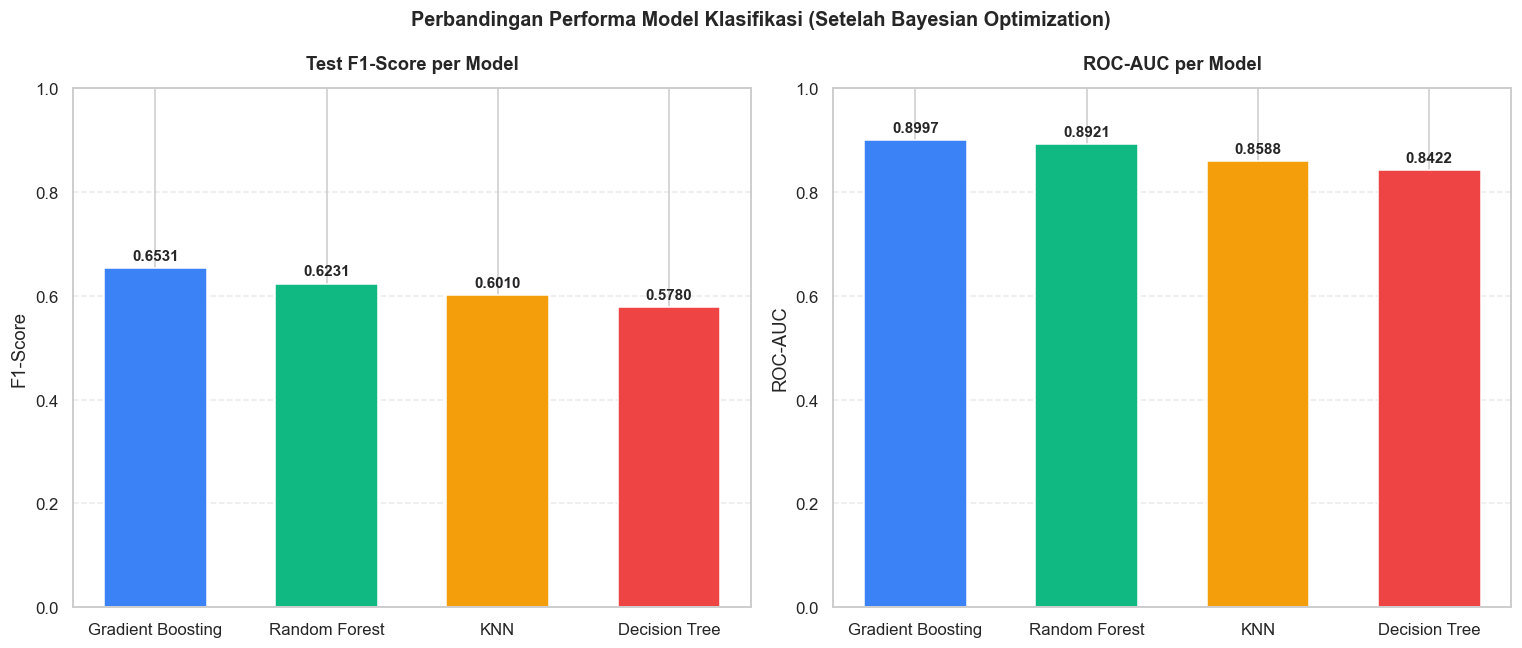

In [28]:
# Visualisasi perbandingan metrik
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

colors_bar = ['#3B82F6', '#10B981', '#F59E0B', '#EF4444']
model_names = results_df['Model'].tolist()

# F1-Score
bars1 = axes[0].bar(model_names, results_df['Test F1'], color=colors_bar,
                    edgecolor='white', width=0.6)
axes[0].set_title('Test F1-Score per Model', fontweight='bold', pad=12)
axes[0].set_ylabel('F1-Score')
axes[0].set_ylim(0, 1.0)
axes[0].grid(axis='y', linestyle='--', alpha=0.4)
for bar, val in zip(bars1, results_df['Test F1']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# ROC-AUC
bars2 = axes[1].bar(model_names, results_df['ROC-AUC'], color=colors_bar,
                    edgecolor='white', width=0.6)
axes[1].set_title('ROC-AUC per Model', fontweight='bold', pad=12)
axes[1].set_ylabel('ROC-AUC')
axes[1].set_ylim(0, 1.0)
axes[1].grid(axis='y', linestyle='--', alpha=0.4)
for bar, val in zip(bars2, results_df['ROC-AUC']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.suptitle('Perbandingan Performa Model Klasifikasi (Setelah Bayesian Optimization)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Interpretasi**: Kedua chart mengonfirmasi urutan yang konsisten — Gradient Boosting unggul pada F1-Score (0.6531) maupun ROC-AUC (0.8997), diikuti Random Forest, KNN, dan Decision Tree. Pola ranking yang sama di kedua metrik menunjukkan bahwa Gradient Boosting tidak hanya lebih baik dalam menyeimbangkan Precision-Recall, tetapi juga dalam memisahkan kedua kelas secara keseluruhan

## 6.4 Evaluasi Detail: Classification Report & Confusion Matrix


──────────────────────────────────────────────────
 Classification Report — KNN
──────────────────────────────────────────────────
              precision    recall  f1-score   support

 Tidak Hujan       0.87      0.94      0.91     22064
       Hujan       0.72      0.51      0.60      6375

    accuracy                           0.85     28439
   macro avg       0.80      0.73      0.75     28439
weighted avg       0.84      0.85      0.84     28439


──────────────────────────────────────────────────
 Classification Report — Decision Tree
──────────────────────────────────────────────────
              precision    recall  f1-score   support

 Tidak Hujan       0.87      0.93      0.90     22064
       Hujan       0.67      0.51      0.58      6375

    accuracy                           0.83     28439
   macro avg       0.77      0.72      0.74     28439
weighted avg       0.82      0.83      0.83     28439


──────────────────────────────────────────────────
 Classification Repo

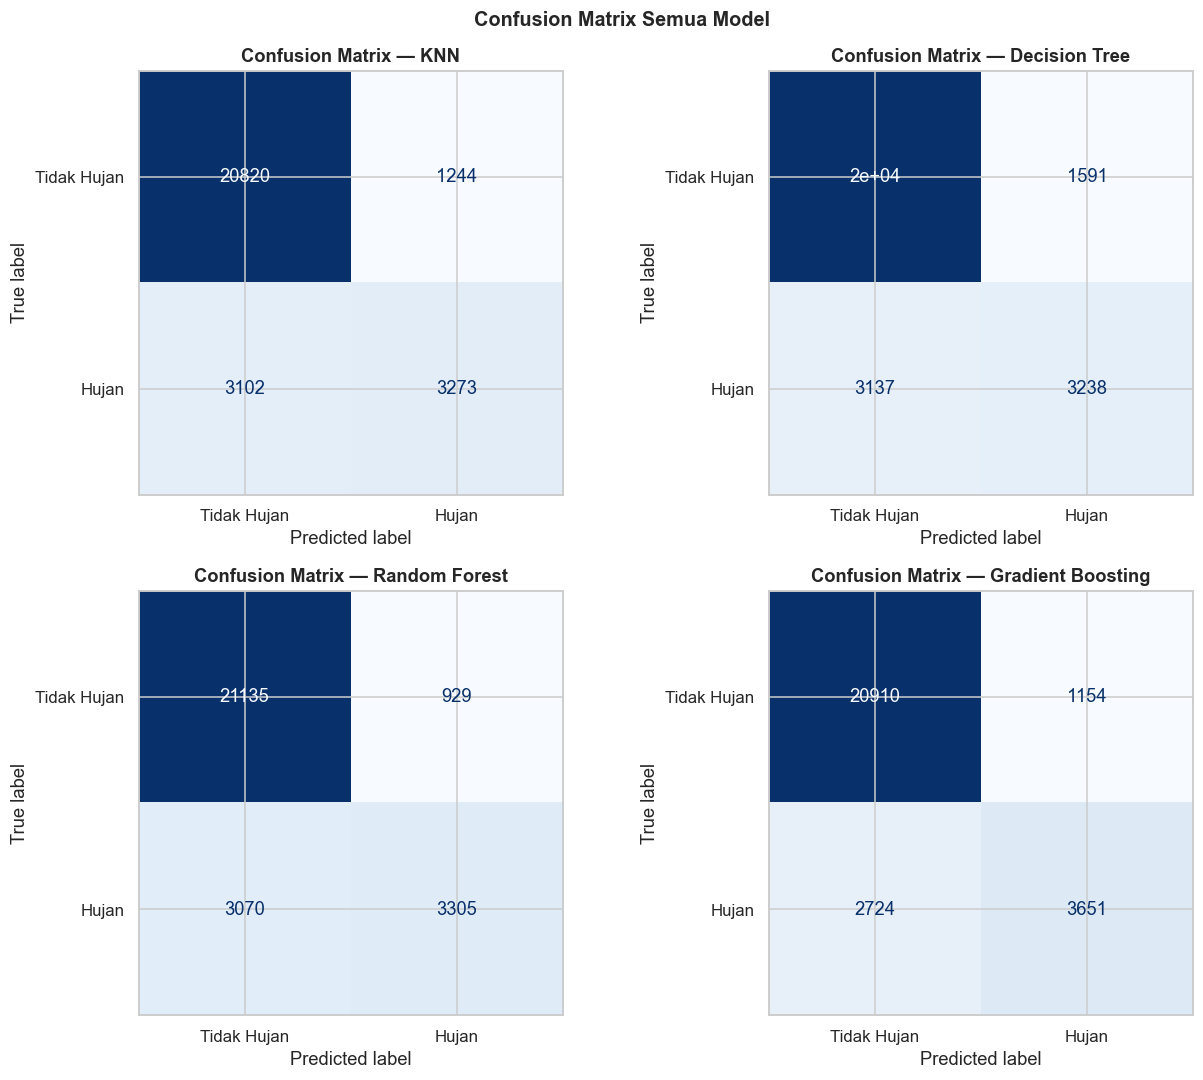

In [29]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, (name, model) in enumerate(best_models.items()):
    X_eval = X_te_sc if name == 'KNN' else X_te

    print(f'\n{"─"*50}')
    print(f' Classification Report — {name}')
    print(f'{"─"*50}')
    y_pred = model.predict(X_eval)
    print(classification_report(y_te, y_pred, target_names=['Tidak Hujan', 'Hujan']))

    ConfusionMatrixDisplay.from_estimator(
        model, X_eval, y_te,
        display_labels=['Tidak Hujan', 'Hujan'],
        cmap='Blues', ax=axes[i], colorbar=False
    )
    axes[i].set_title(f'Confusion Matrix — {name}', fontweight='bold')

plt.suptitle('Confusion Matrix Semua Model', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Interpretasi**: Keempat model konsisten menghasilkan recall kelas Hujan yang rendah (0.51–0.57), menandakan sekitar separuh kejadian hujan masih gagal terdeteksi — konsekuensi langsung dari data imbalanced. Gradient Boosting mencatat performa terbaik dengan recall Hujan tertinggi (0.57) dan False Negative terendah (2.724), menjadikannya model paling andal di antara keempatnya

## 6.5 Kurva ROC — Perbandingan Semua Model

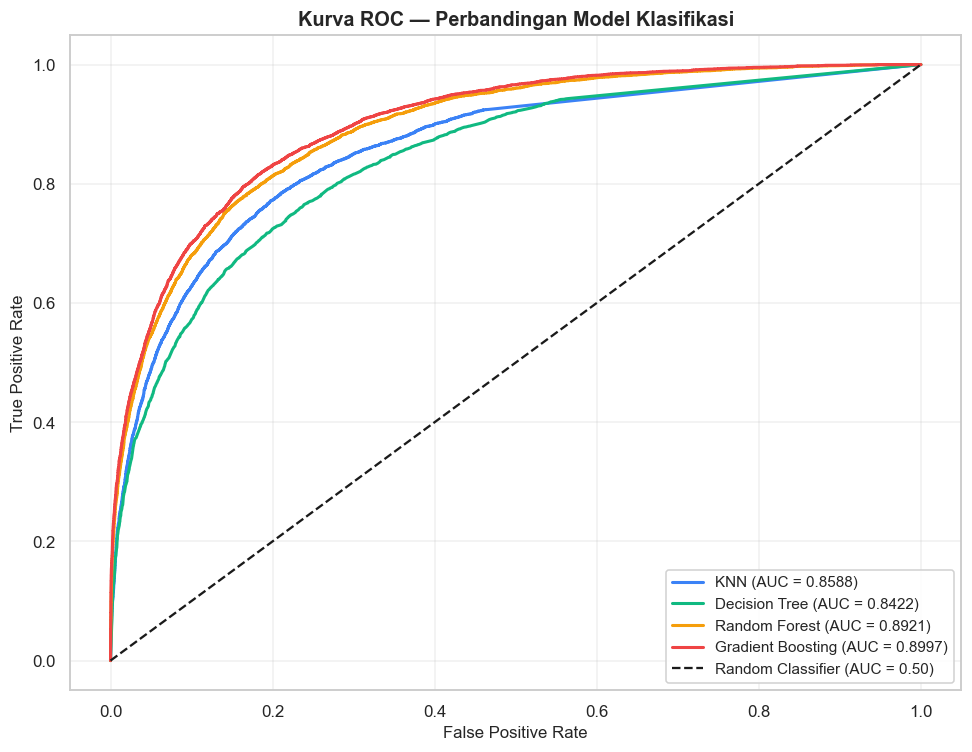

In [30]:
plt.figure(figsize=(9, 7))
palette = ['#3B82F6', '#10B981', '#F59E0B', '#EF4444']

for (name, model), color in zip(best_models.items(), palette):
    X_eval = X_te_sc if name == 'KNN' else X_te
    y_prob = model.predict_proba(X_eval)[:, 1]
    fpr, tpr, _ = roc_curve(y_te, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, color=color, label=f'{name} (AUC = {roc_auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Classifier (AUC = 0.50)')
plt.xlabel('False Positive Rate', fontsize=11)
plt.ylabel('True Positive Rate', fontsize=11)
plt.title('Kurva ROC — Perbandingan Model Klasifikasi', fontweight='bold', fontsize=13)
plt.legend(loc='lower right', fontsize=10, framealpha=0.9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Interpretasi**: Keempat model berada jauh di atas garis diagonal (random classifier, AUC = 0.50), menunjukkan bahwa semua model memiliki kemampuan diskriminasi yang memadai. Gradient Boosting konsisten berada di posisi paling atas sepanjang kurva (AUC = 0.8997), diikuti Random Forest (0.8921), KNN (0.8588), dan Decision Tree (0.8422), urutan yang selaras dengan hasil F1-Score sebelumnya

## 6.6 Feature Importance — Model Tree-based

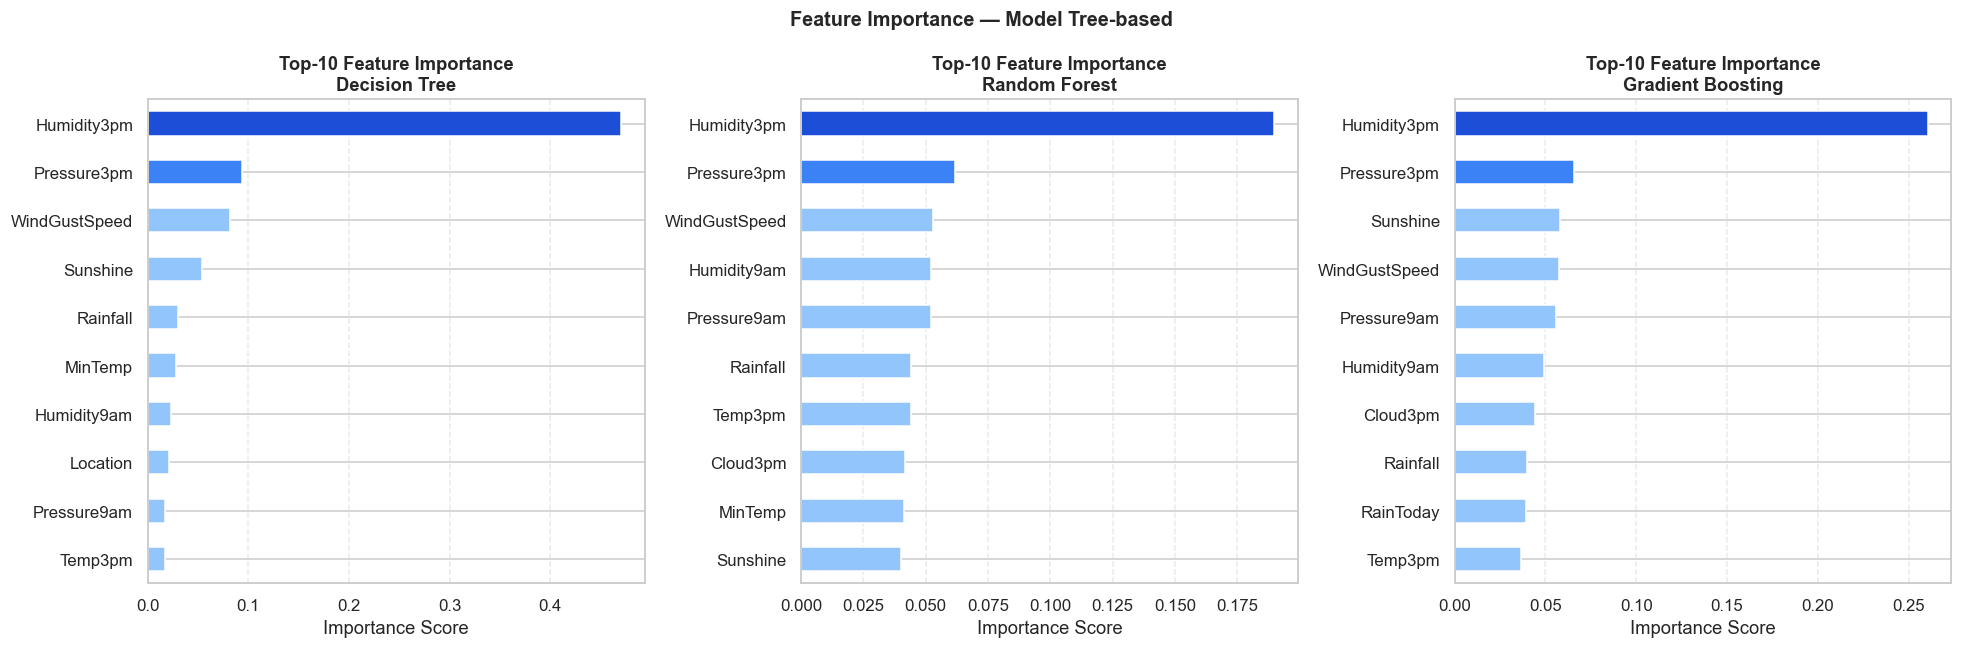

In [31]:
tree_models = ['Decision Tree', 'Random Forest', 'Gradient Boosting']
feature_names = X_m.columns.tolist()

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, name in zip(axes, tree_models):
    model = best_models[name]
    importances = pd.Series(model.feature_importances_, index=feature_names)
    top10 = importances.sort_values(ascending=True).tail(10)

    colors_imp = ['#93C5FD'] * 8 + ['#3B82F6', '#1D4ED8']
    top10.plot(kind='barh', ax=ax, color=colors_imp, edgecolor='white')
    ax.set_title(f'Top-10 Feature Importance\n{name}', fontweight='bold')
    ax.set_xlabel('Importance Score')
    ax.grid(axis='x', linestyle='--', alpha=0.4)

plt.suptitle('Feature Importance — Model Tree-based', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Interpretasi:** Humidity3pm menjadi fitur paling dominan di ketiga model secara konsisten, dengan importance score yang jauh melampaui fitur lainnya — terutama pada Decision Tree yang sangat bergantung pada fitur ini (~0.48). Pressure3pm, WindGustSpeed, dan Sunshine secara konsisten masuk top-5 di semua model, mengonfirmasi bahwa kondisi atmosfer sore hari lebih prediktif dibanding pagi hari untuk memprediksi hujan esok

## 6.7 Hiperparameter Terbaik Hasil Bayesian Optimization

In [32]:
print('=== Ringkasan Hiperparameter Terbaik (Bayesian Optimization) ===')
for name, params in best_params.items():
    print(f'\n► {name}')
    for k, v in params.items():
        print(f'   {k:22s}: {v}')

=== Ringkasan Hiperparameter Terbaik (Bayesian Optimization) ===

► KNN
   leaf_size             : 50
   metric                : manhattan
   n_neighbors           : 8
   weights               : distance

► Decision Tree
   criterion             : entropy
   max_depth             : 20
   max_features          : None
   min_samples_leaf      : 30
   min_samples_split     : 28

► Random Forest
   bootstrap             : False
   max_depth             : 19
   max_features          : sqrt
   min_samples_leaf      : 1
   min_samples_split     : 2
   n_estimators          : 300

► Gradient Boosting
   learning_rate         : 0.10634108127155403
   max_depth             : 8
   max_features          : sqrt
   min_samples_split     : 20
   n_estimators          : 278
   subsample             : 1.0


---
# **Kesimpulan**

**Preprocessing yang dilakukan:**
1. Menyalin data mentah agar data asli tetap terjaga
2. Menghapus baris duplikat
3. Menghapus baris dengan nilai target (`RainTomorrow`) yang kosong
4. Mengekstrak fitur Year, Month, Day dari kolom Date
5. Imputasi missing values: median (numerik) dan modus (kategorikal)
6. Mendeteksi dan menangani outlier dengan metode IQR (winsorizing)
7. Encoding kolom kategorikal (binary mapping & label encoding)
8. Feature scaling dengan StandardScaler

**Output file:**
- `weatherAUS_clean.csv` — data bersih format CSV
- `weatherAUS_clean.parquet` — data bersih format Parquet (lebih efisien)

**Modeling & Optimasi:**
- Empat model klasifikasi digunakan: **KNN**, **Decision Tree**, **Random Forest**, dan **Gradient Boosting**
- Setiap model dioptimasi menggunakan **Bayesian Optimization** (`BayesSearchCV`) dengan 30 iterasi dan Stratified K-Fold (cv=5)
- Evaluasi dilakukan menggunakan **F1-Score** (metrik utama mengingat data imbalanced), **ROC-AUC**, Confusion Matrix, dan Kurva ROC
- Feature importance diekstrak dari ketiga model tree-based; **Humidity3pm** terbukti menjadi fitur paling dominan di seluruh model, diikuti Pressure3pm dan WindGustSpeed
- **Gradient Boosting** merupakan model terbaik dengan Test F1 = **0.6531** dan ROC-AUC = **0.8997**, dan direkomendasikan sebagai pilihan utama untuk prediksi hujan esok hari